#### Implementing simple Chatbot Using LangGraph

In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages


In [7]:
class State(TypedDict):
    messages : Annotated[list, add_messages]

In [8]:
import os
from dotenv import load_dotenv
load_dotenv()

# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()
llm = ChatOpenAI(model="gpt-4o")
llm.invoke("hello")

In [ ]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="openai/gpt-oss-20b")
response = llm_groq.invoke("Hey I am Alice and i like to play cricket")
print(response.content)

Hey Alice! 👋 It’s great to meet a fellow cricket enthusiast. What do you enjoy most about the game—batting, bowling, fielding, or maybe the strategy behind it? If you’ve got any questions, want to talk about your favorite players, or just chat about recent matches, I’m all ears!


#### We Will start With Creating Nodes

In [11]:
def superbot(state : State):
    return {"messeges" : [llm_groq.invoke(state['messages'])]}

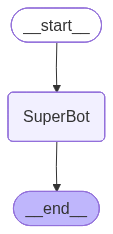

In [12]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile()


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [20]:

## Invocation

graph_builder.invoke({'messages':"Hi,My name is Alice And I like cricket"})

{'messages': [HumanMessage(content='Hi,My name is Alice And I like cricket', additional_kwargs={}, response_metadata={}, id='23d490ef-bd54-40cf-aceb-fa8502871732')]}

#### Streaming The responses

In [26]:
for event in graph_builder.stream({"messages":"Hello My name is Alice"}):
    print(event)

{'SuperBot': None}


In [27]:

for event in graph_builder.stream({"messages":"Hello My name is Alice"}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='Hello My name is Alice', additional_kwargs={}, response_metadata={}, id='cc9cd6d7-642f-4c6b-b5c4-c256dc0fac72')]}


In [28]:

for event in graph_builder.stream({"messages":"Hello My name is Alice"}, stream_mode="values", stream_options={"include_end":True}):
    print(event)

{'messages': [HumanMessage(content='Hello My name is Alice', additional_kwargs={}, response_metadata={}, id='fcd520a5-cc95-4bc8-ac28-bf2daacb4607')]}
